# Clustering Models — Detailed Explanation

Clustering is an unsupervised learning technique used to group similar data points together.

Unlike classification, clustering does not use labeled data.

---

## 🔷 1. K-Means Clustering

### What is it?
K-Means groups data into K clusters based on similarity.

---

### How it works
1. Choose number of clusters (K)
2. Randomly initialize centroids
3. Assign points to nearest centroid
4. Update centroid
5. Repeat until convergence

---

### Strengths
- Fast and simple
- Works well for large datasets

---

### Limitations
- Must choose K
- Sensitive to outliers

---

## 🔷 2. Hierarchical Clustering

### What is it?
Builds clusters step by step (tree structure)

---

### Types
- Agglomerative (bottom-up)
- Divisive (top-down)

---

### Strengths
- No need to specify clusters initially
- Good visualization (dendrogram)

---

### Limitations
- Slow for large datasets

---

## 🔷 3. DBSCAN

### What is it?
Density-based clustering

---

### How it works
- Groups points that are close together
- Detects noise (outliers)

---

### Strengths
- Finds arbitrary shaped clusters
- Handles noise

---

### Limitations
- Hard to tune parameters
- Not good for varying densities

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score

In [12]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [13]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

# 🔥 K-MEANS
## 🔹 Elbow Method

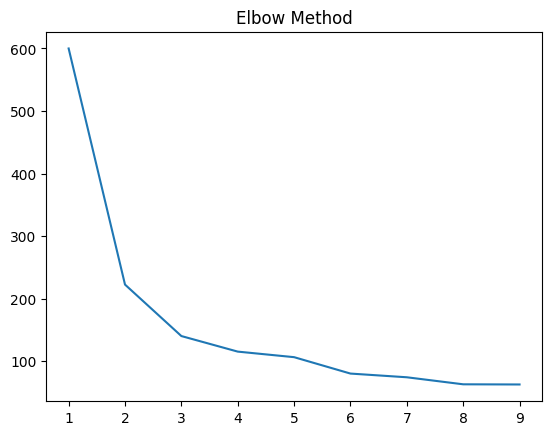

In [14]:
inertia = []

for k in range(1, 10):
    kmeans = KMeans(n_clusters=k)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 10), inertia)
plt.title("Elbow Method")
plt.show()

In [15]:
kmeans = KMeans(n_clusters=3)
kmeans_labels = kmeans.fit_predict(X_scaled)

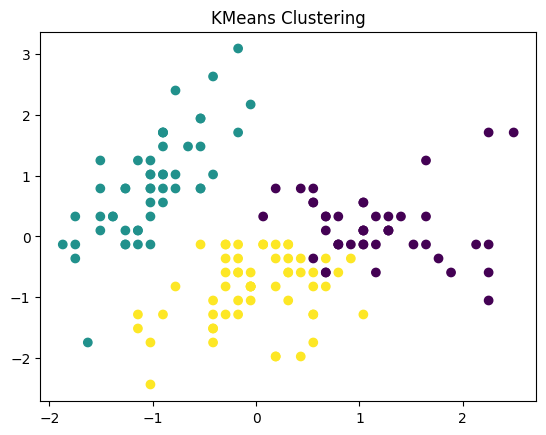

In [16]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], c=kmeans_labels)
plt.title("KMeans Clustering")
plt.show()

# 🔥 HIERARCHICAL

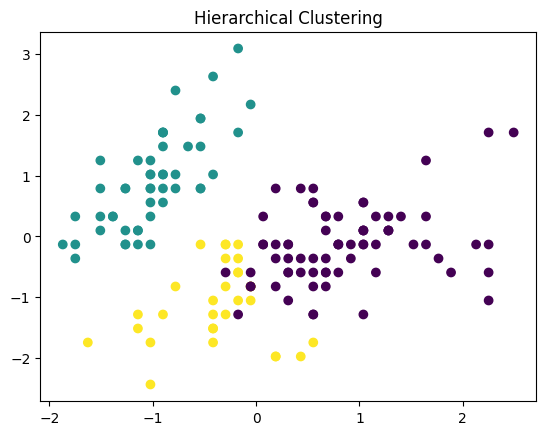

In [17]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=hc_labels)
plt.title("Hierarchical Clustering")
plt.show()

# 🔥 DBSCAN

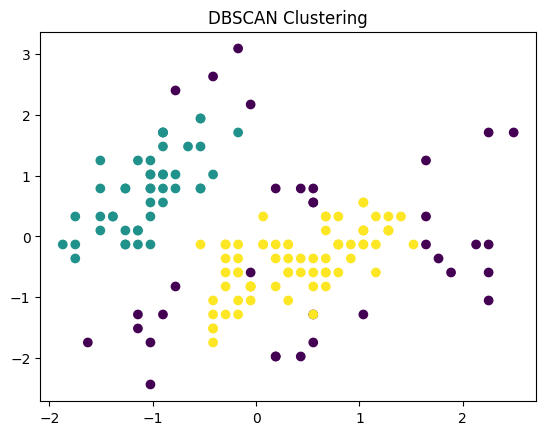

In [18]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

plt.scatter(X_scaled[:,0], X_scaled[:,1], c=db_labels)
plt.title("DBSCAN Clustering")
plt.show()

In [19]:
print("KMeans Silhouette:", silhouette_score(X_scaled, kmeans_labels))
print("Hierarchical Silhouette:", silhouette_score(X_scaled, hc_labels))
print("DBSCAN Silhouette:", silhouette_score(X_scaled, db_labels))

KMeans Silhouette: 0.4630420362927048
Hierarchical Silhouette: 0.446689041028591
DBSCAN Silhouette: 0.35651648142700726


## Conclusion

- KMeans performs well when clusters are spherical
- Hierarchical provides structured clustering
- DBSCAN detects noise and irregular shapes

KMeans usually gives best results for Iris dataset

## 🧠 What is PCA (Simple Explanation)

### 👉 PCA (Principal Component Analysis) = reduces dimensions

Your dataset:

4 features (sepal, petal, etc.)

👉 Hard to visualize in 4D ❌
👉 Convert to 2D → easy to plot ✔

### 🔥 Step 1 — Apply PCA

In [20]:
from sklearn.decomposition import PCA

# Reduce to 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Shape after PCA:", X_pca.shape)

Shape after PCA: (150, 2)


### 🔥 Step 2 — Professional Visualization Function

👉 This is VERY IMPORTANT (clean reusable code)

In [21]:
def plot_clusters(X_pca, labels, title):
    plt.figure(figsize=(8, 6))
    
    scatter = plt.scatter(
        X_pca[:, 0], 
        X_pca[:, 1], 
        c=labels, 
        cmap='viridis',
        s=60,
        edgecolor='k'
    )
    
    plt.title(title, fontsize=14)
    plt.xlabel("Principal Component 1")
    plt.ylabel("Principal Component 2")
    plt.grid(alpha=0.3)
    
    plt.colorbar(scatter)
    plt.show()

### Step 3 — KMeans Visualization

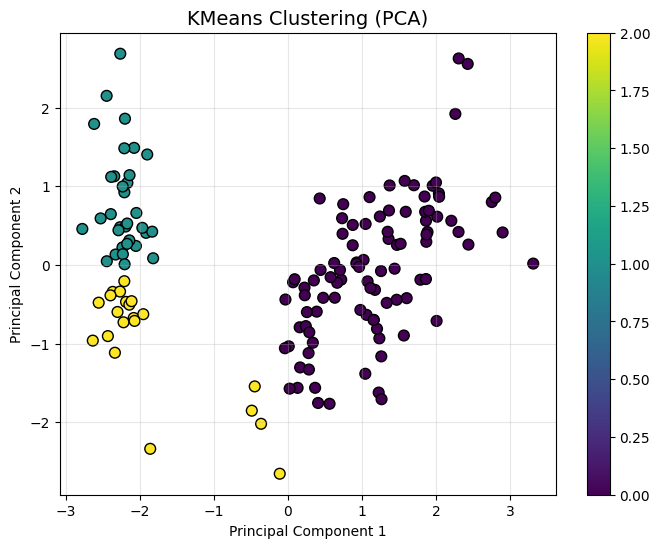

In [22]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)

plot_clusters(X_pca, kmeans_labels, "KMeans Clustering (PCA)")

### Step 4 — Hierarchical Visualization

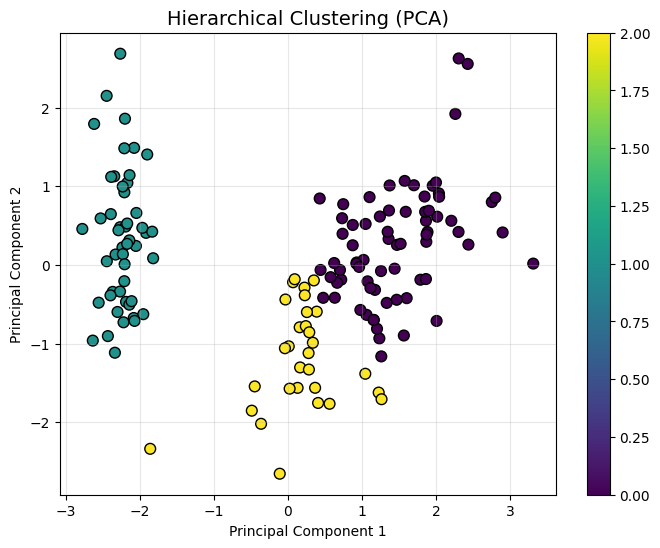

In [23]:
hc = AgglomerativeClustering(n_clusters=3)
hc_labels = hc.fit_predict(X_scaled)

plot_clusters(X_pca, hc_labels, "Hierarchical Clustering (PCA)")

### Step 5 — DBSCAN Visualization

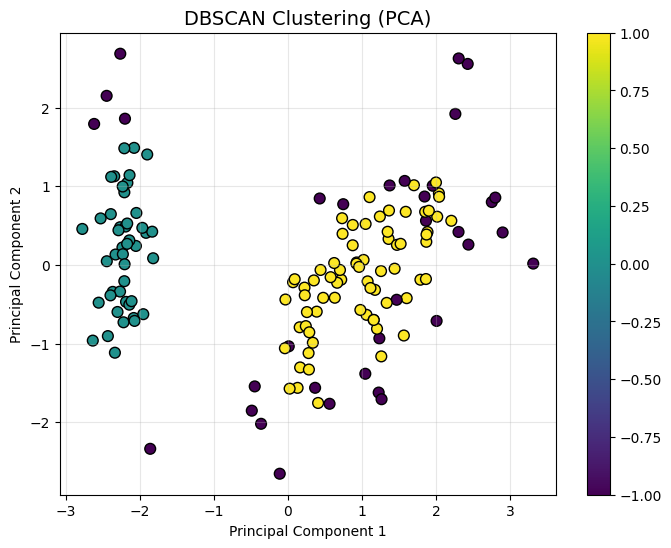

In [24]:
dbscan = DBSCAN(eps=0.5, min_samples=5)
db_labels = dbscan.fit_predict(X_scaled)

plot_clusters(X_pca, db_labels, "DBSCAN Clustering (PCA)")

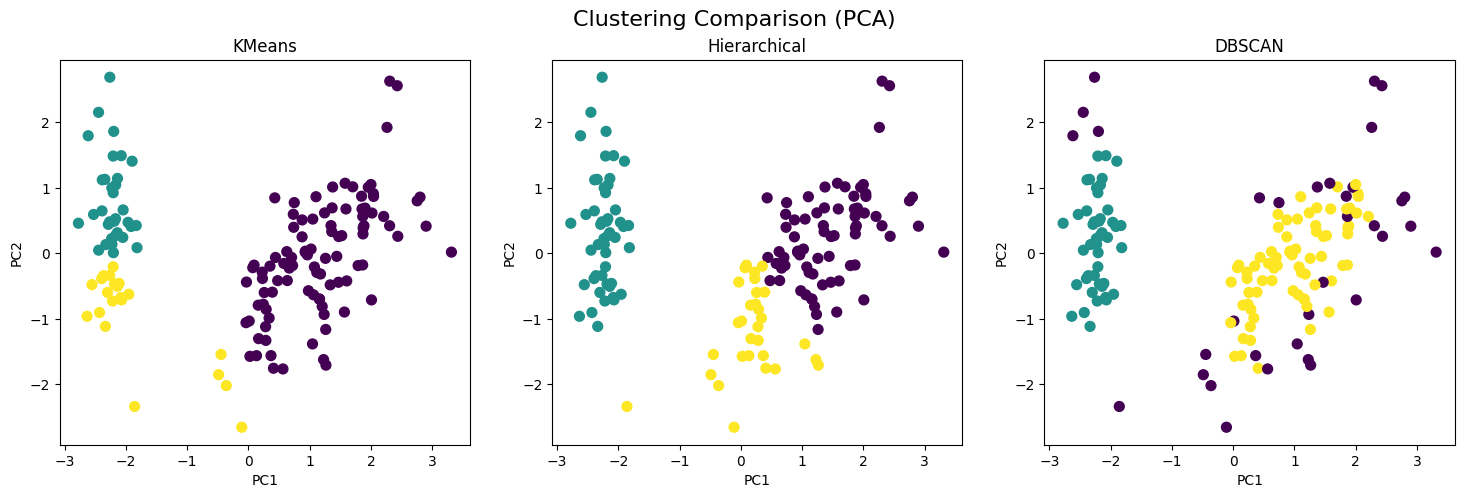

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    ("KMeans", kmeans_labels),
    ("Hierarchical", hc_labels),
    ("DBSCAN", db_labels)
]

for ax, (name, labels) in zip(axes, models):
    ax.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
    ax.set_title(name)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")

plt.suptitle("Clustering Comparison (PCA)", fontsize=16)
plt.show()

🔥 Step 7 — Silhouette Score

In [26]:
from sklearn.metrics import silhouette_score

print("KMeans Score:", silhouette_score(X_scaled, kmeans_labels))
print("Hierarchical Score:", silhouette_score(X_scaled, hc_labels))

# DBSCAN might fail if only one cluster
if len(set(db_labels)) > 1:
    print("DBSCAN Score:", silhouette_score(X_scaled, db_labels))
else:
    print("DBSCAN: Not valid clustering")

KMeans Score: 0.4798814508199818
Hierarchical Score: 0.446689041028591
DBSCAN Score: 0.35651648142700726


# 3D Visualization

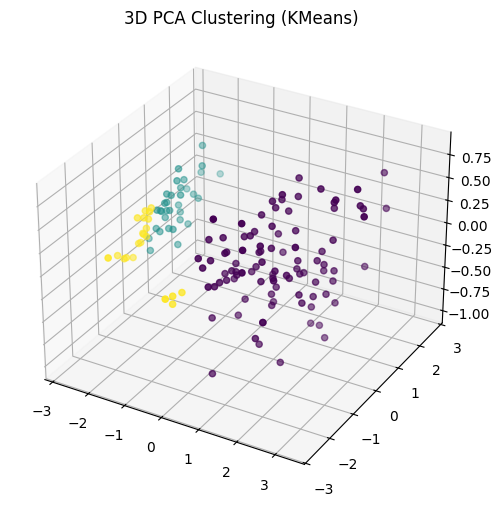

In [27]:
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    X_pca_3d[:, 0], 
    X_pca_3d[:, 1], 
    X_pca_3d[:, 2], 
    c=kmeans_labels, 
    cmap='viridis'
)

ax.set_title("3D PCA Clustering (KMeans)")
plt.show()

## PCA Visualization

To visualize high-dimensional data, Principal Component Analysis (PCA) was used to reduce the dataset from 4 dimensions to 2 dimensions.

This allows us to:
- visually inspect cluster separation
- compare clustering algorithms
- understand structure in the data

KMeans shows well-separated clusters, while DBSCAN identifies noise points.

## 3D Moving Visualization of Clusters using PCA

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, PillowWriter
from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load and prepare data
iris = load_iris()
df = pd.DataFrame(iris.data, columns=iris.feature_names)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

pca = PCA(n_components=3)
X_pca_3d = pca.fit_transform(X_scaled)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(X_scaled)

# Build figure
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    X_pca_3d[:, 0],
    X_pca_3d[:, 1],
    X_pca_3d[:, 2],
    c=labels,
    s=60
)

ax.set_title("3D PCA Clustering Rotation (KMeans on Iris)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")

def update(angle):
    ax.view_init(elev=25, azim=angle)
    return fig,

anim = FuncAnimation(fig, update, frames=np.arange(0, 360, 4), interval=80, blit=False)

# Save animation
gif_path = "moving_3d_clustering.gif"

anim.save(gif_path, writer=PillowWriter(fps=15))

plt.close(fig)
print("Saved at:", gif_path)

Saved at: moving_3d_clustering.gif


This visualization reduces the dataset into 3 principal components using PCA and displays the clusters in a rotating 3D view.  
The animation helps better understand how the clusters are separated in three-dimensional space.